# Signal, Allocation, and Risk Pipeline

This notebook combines the useful parts of `Signals.ipynb` and `Allocation.ipynb` into one deliberately simple pipeline for `SPY`, `EZU`, and `EWJ`:

1. remove copied rows that represent closed-market weekdays;
2. rebuild the existing momentum, trend, volume, currency-risk-reversal, and valid volatility-index features;
3. make expanding-window predictions with purged inner and outer validation;
4. decide after date-$t$ closes and fill at the next valid close;
5. hold the two highest-predicted exchange-traded funds (ETFs) at equal base weights;
6. scale risky exposure toward a fixed volatility target and keep the remainder in cash; and
7. backtest every strategy with the same timing and transaction-cost assumptions.

> **Research status:** exploratory. Earlier notebooks already inspected this history when choosing the feature families and 20-session horizon. The walk-forward predictions below are out of fold, but this dataset is not a new untouched final evaluation.

## 1. Imports and fixed assumptions

The settings below are fixed before viewing this notebook's results. There is no allocation grid or volatility-target search. A basis point is 0.01 percentage point. Cash earns 0% because a historical cash-rate series is not included in the supplied data.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import spearmanr
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "pyproject.toml").exists()
)

ETFS = ["SPY", "EZU", "EWJ"]
HOLDING_SESSIONS = 20
FILL_DELAY_SESSIONS = 1
PURGE_SESSIONS = HOLDING_SESSIONS + FILL_DELAY_SESSIONS
N_OUTER_FOLDS = 5
N_INNER_FOLDS = 4
ALPHA_GRID = np.logspace(-2, 6, 30)

TOP_ASSETS = 2
RISK_LOOKBACK_SESSIONS = 63
TARGET_ANNUAL_VOLATILITY = 0.12
COVARIANCE_SHRINKAGE = 0.20
COST_BPS_PER_SIDE = 5.0
PERIODS_PER_YEAR = 252 / HOLDING_SESSIONS

plt.rcParams["figure.dpi"] = 120

## 2. Load and clean the supplied data

The cleaned ETF file contains 137 weekdays when the New York Stock Exchange was closed. On each one, all three ETF closing prices and all three nonzero volumes are exact copies of the prior row. Those rows are removed before any rolling window, target, or rebalance date is created.

`NKYVF Index PX_LAST` is also excluded. Its unexplained 100-fold jump and extreme scale make it unsuitable as the Japanese analogue of VIX or V2X until its instrument definition and adjustment history are verified.

In [2]:
PRICE_COLUMNS = {etf: f"{etf} US Equity PX_LAST" for etf in ETFS}
VOLUME_COLUMNS = {etf: f"{etf} US Equity PX_VOLUME" for etf in ETFS}
VALID_VOLATILITY_COLUMNS = {
    "SPY": "VIX Index PX_LAST",
    "EZU": "V2X Index PX_LAST",
}
RISK_REVERSAL_COLUMNS = {
    "EURUSD25R1M": "EURUSD25R1M BGN Curncy (R1)",
    "USDJPY25R1M": "USDJPY25R1M BGN Curncy (R2)",
    "EURJPY25R1M": "EURJPY25R1M BGN Curncy (L1)",
}
RISK_REVERSAL_BASE_CURRENCY = {
    "EURUSD25R1M": "EUR",
    "USDJPY25R1M": "USD",
    "EURJPY25R1M": "EUR",
}
ETF_LOCAL_CURRENCY = {"SPY": "USD", "EZU": "EUR", "EWJ": "JPY"}
LOCAL_CURRENCY_PAIRS = {
    "SPY": ["EURUSD25R1M", "USDJPY25R1M"],
    "EZU": ["EURUSD25R1M", "EURJPY25R1M"],
    "EWJ": ["USDJPY25R1M", "EURJPY25R1M"],
}

index_data = pd.read_csv(
    PROJECT_ROOT / "data/Index_ETF_Data_Clean.csv",
    parse_dates=["Dates"],
).sort_values("Dates")
risk_reversal_data = pd.read_csv(
    PROJECT_ROOT / "data/RiskReversalData_Clean.csv",
    parse_dates=["Dates"],
).sort_values("Dates")

assert index_data["Dates"].is_unique
assert risk_reversal_data["Dates"].is_unique

# A copied row has identical price and nonzero volume data for all three ETFs.
session_identity_columns = list(PRICE_COLUMNS.values()) + list(VOLUME_COLUMNS.values())
copied_non_session = index_data[session_identity_columns].eq(
    index_data[session_identity_columns].shift()
).all(axis=1)
removed_non_sessions = int(copied_non_session.sum())
index_data = index_data.loc[~copied_non_session].copy()

market_data = (
    index_data.merge(
        risk_reversal_data,
        on="Dates",
        how="inner",
        validate="one_to_one",
    )
    .sort_values("Dates")
    .set_index("Dates")
)
prices = market_data[list(PRICE_COLUMNS.values())].rename(
    columns={column: etf for etf, column in PRICE_COLUMNS.items()}
)

assert prices.notna().all().all()
assert (prices > 0.0).all().all()
assert pd.Timestamp("2026-01-01") not in prices.index

print(f"Removed copied non-session rows: {removed_non_sessions}")
print(
    f"Valid market sessions: {len(market_data):,}, "
    f"{market_data.index.min().date()} to {market_data.index.max().date()}"
)

Removed copied non-session rows: 137
Valid market sessions: 3,625, 2012-02-27 to 2026-07-28


## 3. Rebuild the existing features

The feature families come directly from `Signals.ipynb`: momentum, price trend, relative volume, local-currency-demand risk reversals, and valid regional volatility indices. Unlike the earlier exploratory notebook, this notebook does not inspect full-sample correlations to select a winner.

Every rolling feature is trailing and uses only data available by the decision close. EWJ deliberately has no volatility-index feature until the Japanese series is repaired.

In [3]:
features = pd.DataFrame(index=market_data.index)

for risk_reversal_name, source_column in RISK_REVERSAL_COLUMNS.items():
    features[f"{risk_reversal_name}_level"] = market_data[source_column]

feature_sets: dict[str, list[str]] = {}

for etf in ETFS:
    price = prices[etf]
    volume = market_data[VOLUME_COLUMNS[etf]]

    features[f"{etf}_mom_20d"] = price.pct_change(20)
    features[f"{etf}_mom_60d"] = price.pct_change(60)
    features[f"{etf}_price_vs_sma50"] = (
        price / price.rolling(50, min_periods=50).mean() - 1.0
    )
    features[f"{etf}_rel_volume_20d"] = (
        volume / volume.rolling(20, min_periods=20).mean() - 1.0
    )

    etf_features = [
        f"{etf}_mom_20d",
        f"{etf}_mom_60d",
        f"{etf}_price_vs_sma50",
        f"{etf}_rel_volume_20d",
    ]

    for risk_reversal_name in LOCAL_CURRENCY_PAIRS[etf]:
        sign = (
            1.0
            if RISK_REVERSAL_BASE_CURRENCY[risk_reversal_name] == ETF_LOCAL_CURRENCY[etf]
            else -1.0
        )
        feature_name = f"{etf}_{risk_reversal_name}_ccy_demand"
        features[feature_name] = sign * features[f"{risk_reversal_name}_level"]
        etf_features.append(feature_name)

    if etf in VALID_VOLATILITY_COLUMNS:
        volatility_index = market_data[VALID_VOLATILITY_COLUMNS[etf]]
        trailing_mean = volatility_index.rolling(60, min_periods=60).mean()
        trailing_std = volatility_index.rolling(60, min_periods=60).std()

        features[f"{etf}_volidx_level"] = volatility_index
        features[f"{etf}_volidx_chg_20d"] = volatility_index.diff(20)
        features[f"{etf}_volidx_zscore_60d"] = (
            volatility_index - trailing_mean
        ) / trailing_std
        etf_features.extend(
            [
                f"{etf}_volidx_level",
                f"{etf}_volidx_chg_20d",
                f"{etf}_volidx_zscore_60d",
            ]
        )

    feature_sets[etf] = etf_features

assert not any("EWJ_volidx" in name for name in feature_sets["EWJ"])
display(pd.Series({etf: len(names) for etf, names in feature_sets.items()}, name="feature_count"))

SPY    9
EZU    9
EWJ    6
Name: feature_count, dtype: int64

## 4. Define a tradable target

At decision close $t$, the model has all date-$t$ features. It does **not** trade at that completed close. It fills at the next valid close, $t+1$, and exits 20 valid market sessions later, at $t+21$.

For ETF $i$, the simple holding-period return is

$$
R_{i,t}=rac{P_{i,t+21}}{P_{i,t+1}}-1,
$$

where $P_{i,t+1}$ is the fill price and $P_{i,t+21}$ is the exit price. The 21-session purge ensures a training label is fully known before the next test decision begins.

In [4]:
entry_prices = prices.shift(-FILL_DELAY_SESSIONS)
exit_prices = prices.shift(-PURGE_SESSIONS)
holding_returns = exit_prices / entry_prices - 1.0

entry_dates = pd.Series(market_data.index, index=market_data.index).shift(
    -FILL_DELAY_SESSIONS
)
exit_dates = pd.Series(market_data.index, index=market_data.index).shift(
    -PURGE_SESSIONS
)

assert (holding_returns.dropna() > -1.0).all().all()

## 5. Purged walk-forward predictions

One Ridge regression is fitted per ETF, as in the existing notebooks. Ridge is a linear regression with an $L_2$ penalty that shrinks unstable coefficients toward zero.

The scaler and Ridge penalty search now sit inside one scikit-learn pipeline, so each inner training fold fits its own scaler. Both inner and outer splits purge 21 sessions, preventing forward-return labels from crossing a validation boundary.

In [5]:
def make_walk_forward_predictions(
    feature_frame: pd.DataFrame,
    target_frame: pd.DataFrame,
    selected_features: dict[str, list[str]],
    target_exit_dates: pd.Series,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Generate purged expanding-window predictions for each ETF.

    Parameters
    ----------
    feature_frame : pandas.DataFrame
        Decision-date features indexed by valid market session.
    target_frame : pandas.DataFrame
        Next-close-to-20-session simple returns, with one column per ETF.
    selected_features : dict[str, list[str]]
        ETF symbols mapped to their fixed feature-column names.
    target_exit_dates : pandas.Series
        Decision dates mapped to the final date used by each target.

    Returns
    -------
    predictions : pandas.DataFrame
        Out-of-fold predicted returns indexed by decision date.
    fold_diagnostics : pandas.DataFrame
        Fold dates, selected Ridge penalties, and rank correlations.
    """
    prediction_series: dict[str, pd.Series] = {}
    fold_records: list[dict[str, object]] = []

    for etf in ETFS:
        feature_names = selected_features[etf]
        modeling_data = pd.concat(
            [feature_frame[feature_names], target_frame[etf].rename("target")],
            axis=1,
        ).dropna().sort_index()
        fold_bounds = np.linspace(
            0, len(modeling_data), N_OUTER_FOLDS + 2
        ).astype(int)
        etf_predictions: list[pd.Series] = []

        for fold in range(1, N_OUTER_FOLDS + 1):
            test_start = fold_bounds[fold]
            test_end = fold_bounds[fold + 1]
            train_end = test_start - PURGE_SESSIONS
            train = modeling_data.iloc[:train_end]
            test = modeling_data.iloc[test_start:test_end]

            model_pipeline = Pipeline(
                [
                    ("scale", StandardScaler()),
                    ("ridge", Ridge(solver="lsqr")),
                ]
            )
            inner_split = TimeSeriesSplit(
                n_splits=N_INNER_FOLDS,
                gap=PURGE_SESSIONS,
            )
            search = GridSearchCV(
                estimator=model_pipeline,
                param_grid={"ridge__alpha": ALPHA_GRID},
                cv=inner_split,
                scoring="neg_mean_squared_error",
                refit=True,
            )
            search.fit(train[feature_names], train["target"])
            predicted_return = search.predict(test[feature_names])

            # The final training target must finish before the test decision.
            final_train_date = train.index[-1]
            assert target_exit_dates.loc[final_train_date] < test.index[0]

            etf_predictions.append(
                pd.Series(predicted_return, index=test.index, name=etf)
            )
            fold_records.append(
                {
                    "etf": etf,
                    "fold": fold,
                    "test_start": test.index[0],
                    "test_end": test.index[-1],
                    "alpha": search.best_params_["ridge__alpha"],
                    "rank_ic": spearmanr(
                        predicted_return, test["target"]
                    ).correlation,
                }
            )

        prediction_series[etf] = pd.concat(etf_predictions).sort_index()

    predictions = pd.DataFrame(prediction_series).dropna().sort_index()
    fold_diagnostics = pd.DataFrame(fold_records)
    return predictions, fold_diagnostics


predictions, fold_diagnostics = make_walk_forward_predictions(
    features,
    holding_returns,
    feature_sets,
    exit_dates,
)

signal_summary = fold_diagnostics.groupby("etf")["rank_ic"].agg(
    ["mean", "std", "min", "max"]
)
print(
    f"Prediction decisions: {len(predictions):,}, "
    f"{predictions.index.min().date()} to {predictions.index.max().date()}"
)
display(signal_summary.round(3))

Prediction decisions: 2,954, 2014-09-26 to 2026-06-26


,mean,std,min,max
etf,,,,
EWJ,0.081,0.126,-0.065,0.256
EZU,0.182,0.132,0.040,0.376
SPY,0.196,0.098,0.099,0.328


## 6. Simple allocation and risk management

The allocation rule is fixed: hold the two ETFs with the highest predicted returns at 50% each. This uses prediction ordering and avoids treating noisy forecast magnitudes as precise portfolio inputs.

The risk layer estimates the base portfolio's annualized volatility from the previous 63 valid daily returns. The sample covariance matrix is shrunk 20% toward its diagonal, reusing the stabilization idea from `Allocation.ipynb`. If estimated volatility exceeds 12%, all ETF weights are reduced proportionally. Leverage is forbidden, and the remainder stays in cash.

In [6]:
def build_top_two_weights(
    predicted_returns: pd.DataFrame,
    decision_dates: pd.DatetimeIndex,
) -> pd.DataFrame:
    """Convert forecast ranks into equal weights for the top two ETFs.

    Parameters
    ----------
    predicted_returns : pandas.DataFrame
        Predicted holding-period returns by decision date and ETF.
    decision_dates : pandas.DatetimeIndex
        Dates on which the portfolio decision is made after the close.

    Returns
    -------
    pandas.DataFrame
        Long-only ETF weights that sum to one before risk scaling.
    """
    weights = pd.DataFrame(0.0, index=decision_dates, columns=ETFS)
    for date in decision_dates:
        selected = predicted_returns.loc[date, ETFS].nlargest(TOP_ASSETS).index
        weights.loc[date, selected] = 1.0 / TOP_ASSETS
    return weights


def apply_volatility_target(
    base_weights: pd.DataFrame,
    daily_asset_returns: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Scale risky weights to a fixed annual volatility target.

    Parameters
    ----------
    base_weights : pandas.DataFrame
        Fully invested ETF weights indexed by decision date.
    daily_asset_returns : pandas.DataFrame
        Historical one-session simple ETF returns.

    Returns
    -------
    risk_weights : pandas.DataFrame
        ETF and cash weights after volatility scaling.
    risk_diagnostics : pandas.DataFrame
        Estimated base volatility, applied scale, and cash weight.
    """
    risk_weights = base_weights.copy()
    diagnostic_rows: list[dict[str, float | pd.Timestamp]] = []

    for date in base_weights.index:
        history = daily_asset_returns.loc[:date, ETFS].tail(
            RISK_LOOKBACK_SESSIONS
        ).dropna()
        assert len(history) == RISK_LOOKBACK_SESSIONS

        sample_covariance = history.cov().to_numpy() * 252.0
        diagonal_covariance = np.diag(np.diag(sample_covariance))
        covariance = (
            (1.0 - COVARIANCE_SHRINKAGE) * sample_covariance
            + COVARIANCE_SHRINKAGE * diagonal_covariance
        )
        base_vector = base_weights.loc[date, ETFS].to_numpy()
        variance = float(base_vector @ covariance @ base_vector)
        estimated_volatility = np.sqrt(max(variance, 0.0))
        risk_scale = (
            min(1.0, TARGET_ANNUAL_VOLATILITY / estimated_volatility)
            if estimated_volatility > 0.0
            else 0.0
        )

        risk_weights.loc[date, ETFS] = base_vector * risk_scale
        diagnostic_rows.append(
            {
                "date": date,
                "estimated_base_volatility": estimated_volatility,
                "risk_scale": risk_scale,
                "cash_weight": 1.0 - risk_scale,
            }
        )

    risk_weights["CASH"] = 1.0 - risk_weights[ETFS].sum(axis=1)
    diagnostics = pd.DataFrame(diagnostic_rows).set_index("date")
    return risk_weights, diagnostics


daily_returns = prices.pct_change()
decision_dates = predictions.index[::HOLDING_SESSIONS]
valid_holding_period = holding_returns.loc[decision_dates, ETFS].notna().all(axis=1)
decision_dates = decision_dates[valid_holding_period.to_numpy()]

base_top_two_weights = build_top_two_weights(predictions, decision_dates)
risk_managed_weights, risk_diagnostics = apply_volatility_target(
    base_top_two_weights, daily_returns
)

assert (risk_managed_weights >= -1e-12).all().all()
assert np.allclose(risk_managed_weights.sum(axis=1), 1.0)
assert (risk_managed_weights[ETFS].max(axis=1) <= 0.5 + 1e-12).all()
assert (entry_dates.loc[decision_dates] > decision_dates).all()
assert (exit_dates.loc[decision_dates] > entry_dates.loc[decision_dates]).all()

print(
    f"Rebalances: {len(decision_dates)}, every {HOLDING_SESSIONS} valid sessions, "
    f"{decision_dates.min().date()} to {decision_dates.max().date()}"
)
display(risk_managed_weights.mean().rename("mean_weight").to_frame().round(3))

Rebalances: 148, every 20 valid sessions, 2014-09-26 to 2026-06-08


,mean_weight
SPY,0.371
EZU,0.197
EWJ,0.256
CASH,0.177


## 7. Backtest with drift and costs

Weights drift during each 20-session holding period. The next rebalance therefore trades from drifted holdings, not from the previous target. Transaction cost equals ETF notional traded multiplied by 5 basis points per side; cash movements are not charged.

All comparisons use the same decision dates, next-close fills, holding returns, and cost model. Sharpe uses annualized arithmetic mean return divided by annualized volatility with a 0% cash-rate assumption; compound annual growth rate (CAGR) is reported separately.

In [7]:
def backtest_weights(
    target_weights: pd.DataFrame,
    asset_holding_returns: pd.DataFrame,
    cost_bps_per_side: float = COST_BPS_PER_SIDE,
) -> pd.DataFrame:
    """Backtest target weights with drift and linear ETF trading costs.

    Parameters
    ----------
    target_weights : pandas.DataFrame
        Decision-date target weights with ETF and `CASH` columns.
    asset_holding_returns : pandas.DataFrame
        Simple ETF returns from next-close fill to 20-session exit.
    cost_bps_per_side : float, default=COST_BPS_PER_SIDE
        Linear cost in basis points for each ETF notional bought or sold.

    Returns
    -------
    pandas.DataFrame
        Gross return, cost, net return, and traded ETF notional by period.
    """
    held_weights = np.array([0.0, 0.0, 0.0, 1.0])
    records: list[dict[str, float | pd.Timestamp]] = []

    for date in target_weights.index:
        target = target_weights.loc[date, ETFS + ["CASH"]].to_numpy(float)
        period_asset_returns = asset_holding_returns.loc[date, ETFS].to_numpy(float)

        traded_notional = float(np.abs(target[:3] - held_weights[:3]).sum())
        gross_return = float(target[:3] @ period_asset_returns)
        transaction_cost = traded_notional * cost_bps_per_side / 10_000.0
        # Pay the trading cost at the fill, then earn the holding-period return.
        net_return = (1.0 - transaction_cost) * (1.0 + gross_return) - 1.0
        assert net_return > -1.0

        # Asset and cash values are normalized by gross ending net asset value.
        ending_gross_value = 1.0 + gross_return
        held_weights = np.concatenate(
            [
                target[:3] * (1.0 + period_asset_returns) / ending_gross_value,
                [target[3] / ending_gross_value],
            ]
        )

        records.append(
            {
                "date": date,
                "gross": gross_return,
                "cost": transaction_cost,
                "net": net_return,
                "traded_notional": traded_notional,
            }
        )

    return pd.DataFrame(records).set_index("date")


def performance_statistics(backtest: pd.DataFrame) -> pd.Series:
    """Calculate return, risk, drawdown, turnover, and cost statistics.

    Parameters
    ----------
    backtest : pandas.DataFrame
        Period-level output from `backtest_weights`.

    Returns
    -------
    pandas.Series
        Performance statistics stored as decimal returns and ratios.
    """
    net_returns = backtest["net"]
    growth = (1.0 + net_returns).cumprod()
    running_peak = np.maximum.accumulate(
        np.concatenate([[1.0], growth.to_numpy()])
    )[1:]
    annual_mean_return = net_returns.mean() * PERIODS_PER_YEAR
    annual_volatility = net_returns.std() * np.sqrt(PERIODS_PER_YEAR)

    return pd.Series(
        {
            "total_return": growth.iloc[-1] - 1.0,
            "cagr": growth.iloc[-1] ** (PERIODS_PER_YEAR / len(growth)) - 1.0,
            "ann_mean_return": annual_mean_return,
            "ann_vol": annual_volatility,
            "sharpe": (
                annual_mean_return / annual_volatility
                if annual_volatility > 0.0
                else np.nan
            ),
            "max_drawdown": (growth.to_numpy() / running_peak - 1.0).min(),
            "ann_traded_notional": (
                backtest["traded_notional"].mean() * PERIODS_PER_YEAR
            ),
            "ann_cost": backtest["cost"].mean() * PERIODS_PER_YEAR,
        }
    )

In [8]:
def add_cash_column(etf_weights: pd.DataFrame) -> pd.DataFrame:
    """Return ETF weights with residual cash added as a final column.

    Parameters
    ----------
    etf_weights : pandas.DataFrame
        ETF-only weights indexed by decision date.

    Returns
    -------
    pandas.DataFrame
        Copy of the weights with a residual `CASH` column.
    """
    result = etf_weights.copy()
    result["CASH"] = 1.0 - result[ETFS].sum(axis=1)
    return result


single_asset_weights = pd.DataFrame(0.0, index=decision_dates, columns=ETFS)
for date in decision_dates:
    single_asset_weights.loc[date, predictions.loc[date, ETFS].idxmax()] = 1.0

equal_weight = pd.DataFrame(
    np.full((len(decision_dates), len(ETFS)), 1.0 / len(ETFS)),
    index=decision_dates,
    columns=ETFS,
)
spy_only = pd.DataFrame(0.0, index=decision_dates, columns=ETFS)
spy_only["SPY"] = 1.0

strategy_weights = {
    "risk_managed_top_two": risk_managed_weights,
    "top_two_unscaled": add_cash_column(base_top_two_weights),
    "single_asset_rotation": add_cash_column(single_asset_weights),
    "equal_weight": add_cash_column(equal_weight),
    "SPY_only": add_cash_column(spy_only),
}

for weights in strategy_weights.values():
    assert np.allclose(weights.sum(axis=1), 1.0)

strategy_backtests = {
    name: backtest_weights(weights, holding_returns)
    for name, weights in strategy_weights.items()
}
performance = pd.DataFrame(
    {name: performance_statistics(result) for name, result in strategy_backtests.items()}
).T
display(performance.round(4))

,total_return,cagr,ann_mean_return,ann_vol,sharpe,max_drawdown,ann_traded_notional,ann_cost
risk_managed_top_two,1.4037,0.0775,0.0824,0.1196,0.6894,-0.2756,5.2188,0.0026
top_two_unscaled,2.6493,0.1165,0.1221,0.1491,0.8187,-0.2785,5.4131,0.0027
single_asset_rotation,2.9917,0.1251,0.1301,0.1521,0.8556,-0.2440,5.3635,0.0027
equal_weight,2.1042,0.1012,0.1068,0.1404,0.7606,-0.2556,0.2610,0.0001
SPY_only,3.6300,0.1394,0.1417,0.1439,0.9847,-0.2440,0.0851,0.0000


## 8. Portfolio behavior

The first chart shows what the risk layer actually holds. The second compares net wealth and drawdown. Risk management is intended to control exposure; it is not expected to create forecasting skill.

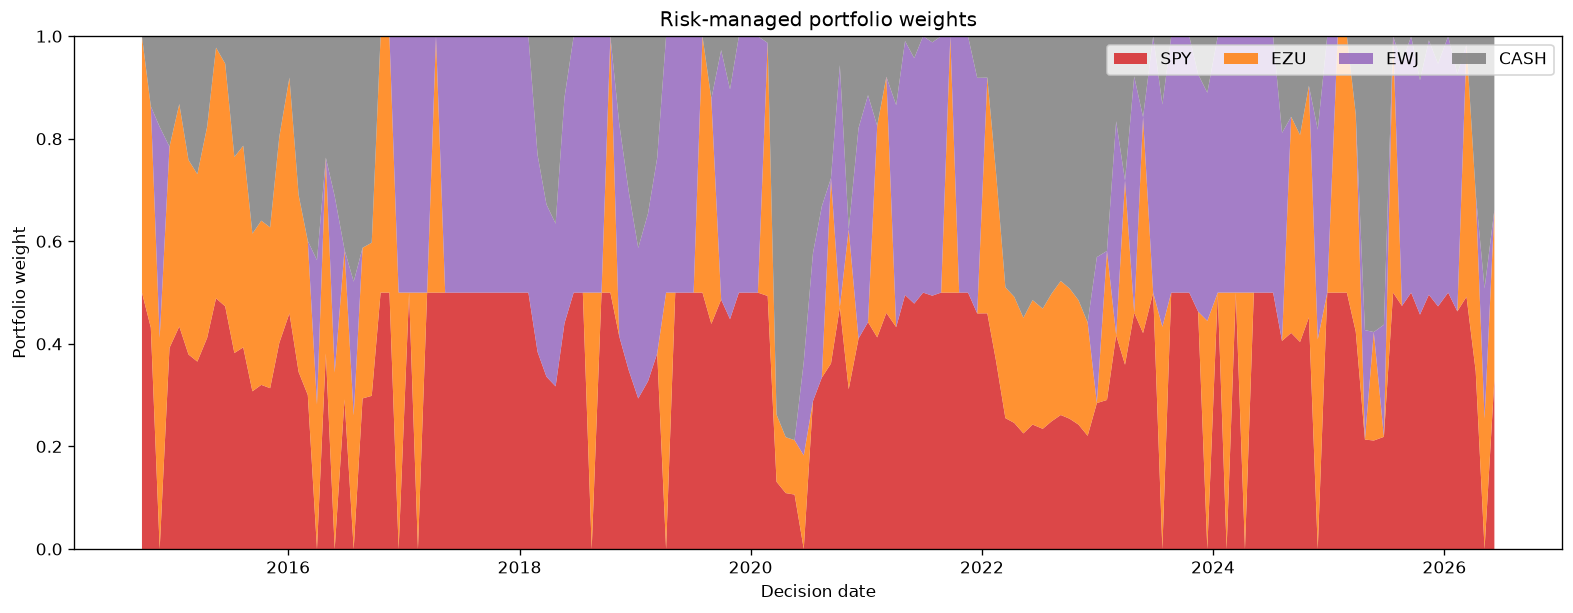

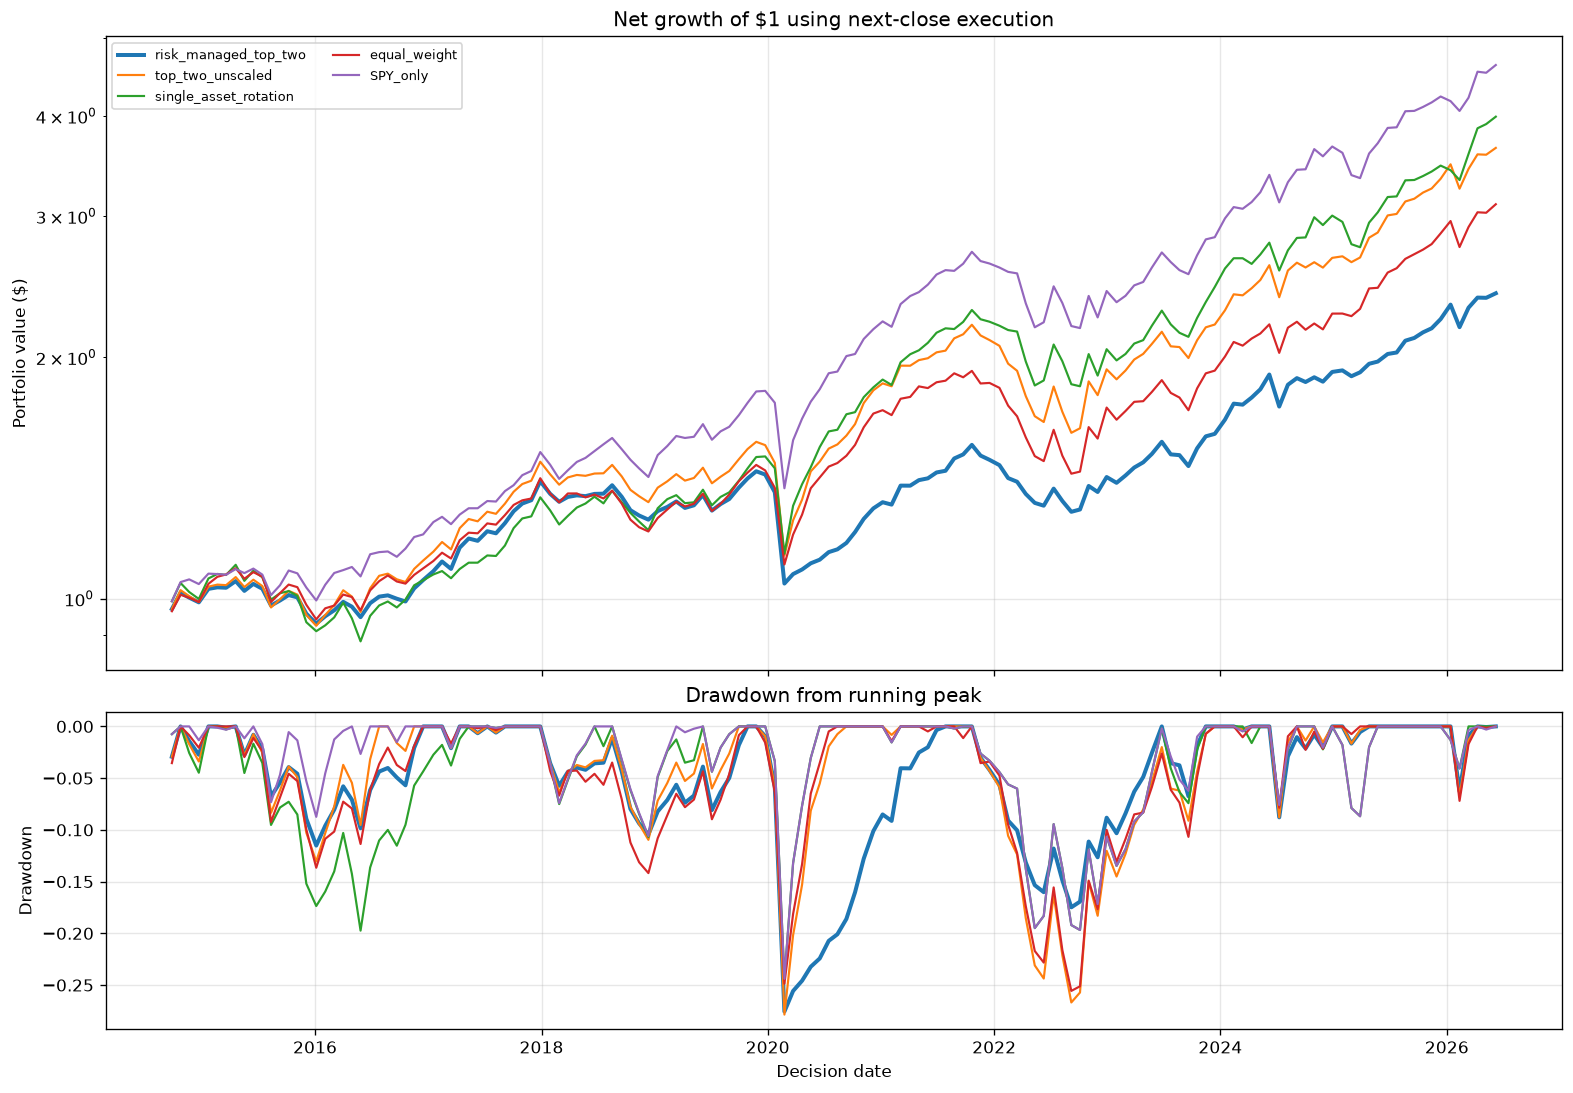

In [9]:
weight_colors = ["#d62728", "#ff7f0e", "#9467bd", "#7f7f7f"]
fig, ax = plt.subplots(figsize=(13, 5), constrained_layout=True)
ax.stackplot(
    risk_managed_weights.index.to_numpy(),
    *[risk_managed_weights[column].to_numpy() for column in ETFS + ["CASH"]],
    labels=ETFS + ["CASH"],
    colors=weight_colors,
    alpha=0.85,
)
ax.set_title("Risk-managed portfolio weights")
ax.set_xlabel("Decision date")
ax.set_ylabel("Portfolio weight")
ax.set_ylim(0.0, 1.0)
ax.legend(loc="upper right", ncol=4)
plt.show()

net_returns = pd.DataFrame(
    {name: result["net"] for name, result in strategy_backtests.items()}
)
growth = (1.0 + net_returns).cumprod()
drawdown = growth / growth.cummax().clip(lower=1.0) - 1.0

fig, (growth_ax, drawdown_ax) = plt.subplots(
    2,
    1,
    figsize=(13, 9),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={"height_ratios": [2, 1]},
)
for strategy in growth.columns:
    line_width = 2.4 if strategy == "risk_managed_top_two" else 1.3
    growth_ax.plot(growth.index, growth[strategy], label=strategy, linewidth=line_width)
    drawdown_ax.plot(drawdown.index, drawdown[strategy], linewidth=line_width)

growth_ax.set_title("Net growth of $1 using next-close execution")
growth_ax.set_ylabel("Portfolio value ($)")
growth_ax.set_yscale("log")
growth_ax.legend(ncol=2, fontsize=8)
growth_ax.grid(True, alpha=0.3)
drawdown_ax.set_title("Drawdown from running peak")
drawdown_ax.set_xlabel("Decision date")
drawdown_ax.set_ylabel("Drawdown")
drawdown_ax.grid(True, alpha=0.3)
plt.show()

## 9. Trace one decision end to end

This trace makes the timing and accounting inspectable: information is observed at the decision close, the trade fills at the next valid close, and profit and loss ends 20 valid sessions after the fill.

In [10]:
trace_date = decision_dates[0]
trace = pd.Series(
    {
        "decision_date": trace_date.date(),
        "fill_date": entry_dates.loc[trace_date].date(),
        "exit_date": exit_dates.loc[trace_date].date(),
        **{f"predicted_{etf}": predictions.loc[trace_date, etf] for etf in ETFS},
        **{f"weight_{asset}": risk_managed_weights.loc[trace_date, asset] for asset in ETFS + ["CASH"]},
        "estimated_base_volatility": risk_diagnostics.loc[
            trace_date, "estimated_base_volatility"
        ],
        "risk_scale": risk_diagnostics.loc[trace_date, "risk_scale"],
        **{f"realized_{etf}": holding_returns.loc[trace_date, etf] for etf in ETFS},
        **strategy_backtests["risk_managed_top_two"].loc[trace_date].to_dict(),
    },
    name="first_rebalance",
)
display(trace.to_frame())

,first_rebalance
decision_date,2014-09-26
fill_date,2014-09-29
exit_date,2014-10-27
predicted_SPY,0.023052
predicted_EZU,0.019761
predicted_EWJ,0.012167
weight_SPY,0.5
weight_EZU,0.5
weight_EWJ,0.0
weight_CASH,0.0


## 10. Rebalance-phase robustness

Selecting every twentieth prediction depends on where counting begins. The check below runs all 20 possible starting offsets and reports the minimum, median, and maximum result. It is a robustness diagnostic, not another selection step.

In [11]:
def evaluate_rebalance_phase(offset: int) -> pd.Series:
    """Evaluate the fixed risk-managed strategy for one rebalance offset.

    Parameters
    ----------
    offset : int
        Starting prediction-row offset from zero through 19.

    Returns
    -------
    pandas.Series
        Performance statistics for the fixed strategy at this offset.
    """
    phase_dates = predictions.index[offset::HOLDING_SESSIONS]
    valid = holding_returns.loc[phase_dates, ETFS].notna().all(axis=1)
    phase_dates = phase_dates[valid.to_numpy()]
    phase_base = build_top_two_weights(predictions, phase_dates)
    phase_weights, _ = apply_volatility_target(phase_base, daily_returns)
    phase_backtest = backtest_weights(phase_weights, holding_returns)
    result = performance_statistics(phase_backtest)
    result["offset"] = offset
    return result


phase_results = pd.DataFrame(
    [evaluate_rebalance_phase(offset) for offset in range(HOLDING_SESSIONS)]
).set_index("offset")
phase_summary = phase_results[["cagr", "ann_vol", "sharpe", "max_drawdown"]].agg(
    ["min", "median", "max"]
)
display(phase_summary.round(4))

,cagr,ann_vol,sharpe,max_drawdown
min,0.0707,0.1113,0.5959,-0.2822
median,0.0808,0.1234,0.6899,-0.2231
max,0.0866,0.1337,0.8052,-0.1773


## Conclusion and remaining limitations

This notebook fixes the known mechanical problems without adding a complex model or optimizer: fake sessions are removed, `NKYVF` is excluded, validation is purged, trading occurs one valid close after the decision, allocation is fixed, and the risk layer only scales exposure and holds cash.

The remaining limitations are important:

- the historical sample was already used for earlier feature and horizon exploration, so results are exploratory;
- the source files do not provide intraday timestamps, so next-close execution is a conservative convention rather than a reconstruction of actual orders;
- the adjustment and dividend treatment of `PX_LAST` still needs vendor confirmation;
- cash earns 0%, and costs are a simple linear estimate without spread variation or market impact; and
- the Japanese volatility feature is omitted, not repaired.

A genuinely untouched future period is required before treating the strategy as validated.